In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [56]:
#load delta t data from file
path_delta_t = '/raid1/genli/Data_D2O/run19520_19529_dt0-20000_sa0-100000/Total/Total_run_19520_19529_delta_t_histogram.pkl'

#load delta t data histogram from file
delta_t = np.load(path_delta_t, allow_pickle=True)
#print attributes of delta_t
print(delta_t.keys())
#extract data from delta_t
hist_delta_t = delta_t['hist']
centers_delta_t = delta_t['bin_centers']   
err_delta_t = delta_t['errorbars']

dict_keys(['hist', 'bin_centers', 'errorbars'])


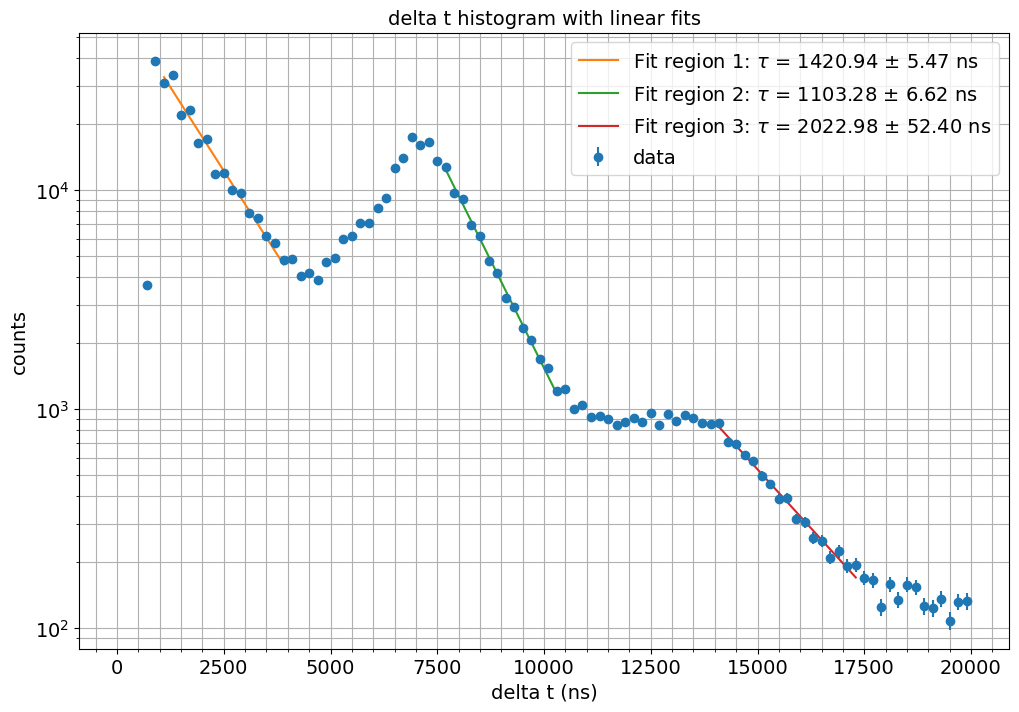

In [57]:
# Fit the log of the histogram with linear function, y = a + b*x, and \tau = 1/b
def linear(x, a, b):
    return a + b*x

# Fit the log of the histogram
# Define three regions for fitting
region_1 = (centers_delta_t > 1000) & (centers_delta_t < 4000)
region_2 = (centers_delta_t > 7500) & (centers_delta_t < 10500)
region_3 = (centers_delta_t > 14000) & (centers_delta_t < 17500)

regions = [region_1, region_2, region_3]

# Plot the histogram again
plt.figure(figsize=(12, 8))
plt.errorbar(centers_delta_t, hist_delta_t, yerr=err_delta_t, fmt='o', label='data')
plt.yscale('log')
plt.xlabel('delta t (ns)', fontsize=14)
plt.ylabel('counts', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('delta t histogram with linear fits', fontsize=14)
plt.legend(fontsize=14)

# Enable minor ticks so that the grid has more reference points.
plt.minorticks_on()
plt.grid(which='both')

# Fit and plot the linear fits for each region
for i, region in enumerate(regions):
    x_fit = centers_delta_t[region]
    y_fit = np.log(hist_delta_t[region])
    y_err_fit = err_delta_t[region] / hist_delta_t[region]  # Error propagation for log(y)
    
    # Perform the fit
    popt, pcov = curve_fit(linear, x_fit, y_fit, sigma=y_err_fit, absolute_sigma=True)
    
    # Calculate the lifetime tau
    tau = -1 / popt[1]
    tau_err = np.sqrt(pcov[1, 1]) / popt[1]**2
    
    # Plot the fit
    plt.plot(x_fit, np.exp(linear(x_fit, *popt)), label=f'Fit region {i+1}: $\\tau$ = {tau:.2f} ± {tau_err:.2f} ns')

plt.legend(fontsize=14)
plt.show()

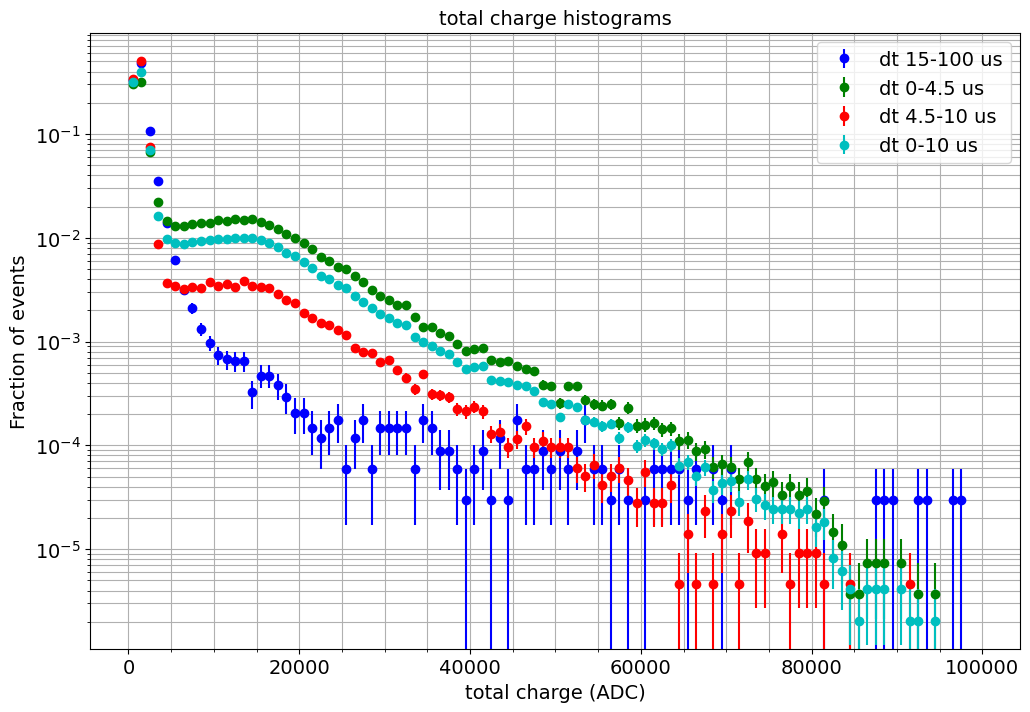

In [58]:
#load several total charge histograms from files, normalized by the number of events, and plot them
dt_15000_100000 = np.load('/raid1/genli/Data_D2O/run19520_19529_dt15000-100000_sa0-100000/Total/Total_run_19520_19529_sum_area_histogram.pkl', allow_pickle=True)
dt_0_4500 = np.load('/raid1/genli/Data_D2O/run19520_19529_dt0-4500_sa0-100000/Total/Total_run_19520_19529_sum_area_histogram.pkl', allow_pickle=True)
dt_4500_10000 = np.load('/raid1/genli/Data_D2O/run19520_19529_dt4500-10000_sa0-100000/Total/Total_run_19520_19529_sum_area_histogram.pkl', allow_pickle=True)
dt_0_10000 = np.load('/raid1/genli/Data_D2O/run19520_19529_dt0-10000_sa0-100000/Total/Total_run_19520_19529_sum_area_histogram.pkl', allow_pickle=True)

#calculate the errorbars
dt_15000_100000['errorbars'] = dt_15000_100000['errorbars'] / np.sum(dt_15000_100000['hist'])
dt_0_4500['errorbars'] = dt_0_4500['errorbars'] / np.sum(dt_0_4500['hist'])
dt_4500_10000['errorbars'] = dt_4500_10000['errorbars'] / np.sum(dt_4500_10000['hist'])
dt_0_10000['errorbars'] = dt_0_10000['errorbars'] / np.sum(dt_0_10000['hist'])

#normalize the histograms
dt_15000_100000['hist'] = dt_15000_100000['hist'] / np.sum(dt_15000_100000['hist'])
dt_0_4500['hist'] = dt_0_4500['hist'] / np.sum(dt_0_4500['hist'])
dt_4500_10000['hist'] = dt_4500_10000['hist'] / np.sum(dt_4500_10000['hist'])
dt_0_10000['hist'] = dt_0_10000['hist'] / np.sum(dt_0_10000['hist'])

colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

#plot the histograms
plt.figure(figsize=(12, 8))
plt.errorbar(dt_15000_100000['bin_centers'], dt_15000_100000['hist'], yerr=dt_15000_100000['errorbars'], fmt='o', label='dt 15-100 us', color=colors[0])
plt.errorbar(dt_0_4500['bin_centers'], dt_0_4500['hist'], yerr=dt_0_4500['errorbars'], fmt='o', label='dt 0-4.5 us', color=colors[1])
plt.errorbar(dt_4500_10000['bin_centers'], dt_4500_10000['hist'], yerr=dt_4500_10000['errorbars'], fmt='o', label='dt 4.5-10 us', color=colors[2])
plt.errorbar(dt_0_10000['bin_centers'], dt_0_10000['hist'], yerr=dt_0_10000['errorbars'], fmt='o', label='dt 0-10 us', color=colors[3])
plt.yscale('log')
plt.xlabel('total charge (ADC)', fontsize=14)
plt.ylabel('Fraction of events', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('total charge histograms', fontsize=14)
plt.legend(fontsize=14)
plt.minorticks_on()
plt.grid(which='both')
plt.show()


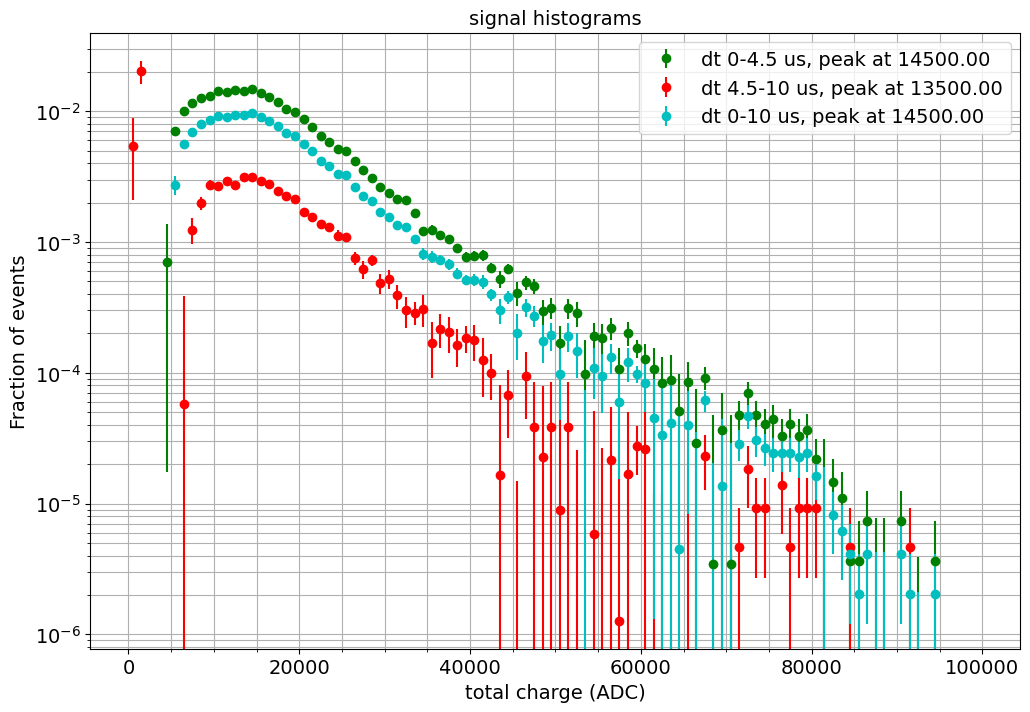

In [60]:
#choose dt_15000_100000 as bg, others as signal, subtracte bg
dt_0_4500_sig = dt_0_4500['hist'] - dt_15000_100000['hist']
dt_4500_10000_sig = dt_4500_10000['hist'] - dt_15000_100000['hist']
dt_0_10000_sig = dt_0_10000['hist'] - dt_15000_100000['hist']

#calculate the errorbars
dt_0_4500_sig_err = np.sqrt(dt_0_4500['errorbars']**2 + dt_15000_100000['errorbars']**2)
dt_4500_10000_sig_err = np.sqrt(dt_4500_10000['errorbars']**2 + dt_15000_100000['errorbars']**2)
dt_0_10000_sig_err = np.sqrt(dt_0_10000['errorbars']**2 + dt_15000_100000['errorbars']**2)

#find peak from total charge 5000 to 100000
crop_bincenter_0_4500 = dt_0_4500['bin_centers'][(dt_0_4500['bin_centers'] > 5000) & (dt_0_4500['bin_centers'] < 100000)]
crop_hist_0_4500 = dt_0_4500_sig[(dt_0_4500['bin_centers'] > 5000) & (dt_0_4500['bin_centers'] < 100000)]
peak_0_4500 = crop_bincenter_0_4500[np.argmax(crop_hist_0_4500)]

crop_bincenter_4500_10000 = dt_4500_10000['bin_centers'][(dt_4500_10000['bin_centers'] > 5000) & (dt_4500_10000['bin_centers'] < 100000)]
crop_hist_4500_10000 = dt_4500_10000_sig[(dt_4500_10000['bin_centers'] > 5000) & (dt_4500_10000['bin_centers'] < 100000)]
peak_4500_10000 = crop_bincenter_4500_10000[np.argmax(crop_hist_4500_10000)]

crop_bincenter_0_10000 = dt_0_10000['bin_centers'][(dt_0_10000['bin_centers'] > 5000) & (dt_0_10000['bin_centers'] < 100000)]
crop_hist_0_10000 = dt_0_10000_sig[(dt_0_10000['bin_centers'] > 5000) & (dt_0_10000['bin_centers'] < 100000)]
peak_0_10000 = crop_bincenter_0_10000[np.argmax(crop_hist_0_10000)]

#plot the signal histograms
plt.figure(figsize=(12, 8))
plt.errorbar(dt_0_4500['bin_centers'], dt_0_4500_sig, yerr=dt_0_4500_sig_err, fmt='o', label='dt 0-4.5 us, peak at %.2f' % peak_0_4500, color=colors[1])
plt.errorbar(dt_4500_10000['bin_centers'], dt_4500_10000_sig, yerr=dt_4500_10000_sig_err, fmt='o', label='dt 4.5-10 us, peak at %.2f' % peak_4500_10000, color=colors[2])
plt.errorbar(dt_0_10000['bin_centers'], dt_0_10000_sig, yerr=dt_0_10000_sig_err, fmt='o', label= 'dt 0-10 us, peak at %.2f' % peak_0_10000, color=colors[3])
plt.yscale('log')
plt.xlabel('total charge (ADC)', fontsize=14)
plt.ylabel('Fraction of events', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('signal histograms', fontsize=14)
plt.legend(fontsize=14)
plt.minorticks_on()
plt.grid(which='both')
plt.show()